# Week 13: Domain Adaptation - Self-Training (Pseudo-Labeling)
**Task 5 | Muhammadjon Merzaqulov**

### Overview
This notebook implements Domain Adaptation using the **Self-Training** approach. Unlike the Few-Shot method which requires human-annotated labels, this method is completely unsupervised for the target domain.

**The Pipeline:**
1. **Load Pre-trained Model:** Loads the RoBERTa model fine-tuned on IMDb (Week 12).
2. **Zero-Shot Evaluation:** Establishes a baseline on the Twitter test set.
3. **Pseudo-Labeling:** Runs inference on thousands of unlabelled tweets (`tweet_unlabelled_pool.csv`).
4. **Threshold Logic (Handling the missing Neutral class):**
   - If probability of Positive > 0.90 → Assign `2` (Positive)
   - If probability of Negative > 0.90 → Assign `0` (Negative)
   - If both probabilities are < 0.75 → Assign `1` (Neutral)
5. **Fine-Tuning:** Re-trains the model on these generated pseudo-labels.
6. **Evaluation:** Compares the final adapted model against the Zero-Shot baseline.

## 0. Environment Setup

In [1]:
!git clone https://github.com/imrushka/ML_group_project
%cd ML_group_project

%pip install -q datasets emoji pyarrow joblib
%pip install -q transformers accelerate torch scikit-learn matplotlib

Cloning into 'ML_group_project'...
remote: Enumerating objects: 48, done.
remote: Counting objects: 100% (48/48), done.
remote: Compressing objects: 100% (34/34), done.
remote: Total 48 (delta 19), reused 41 (delta 13), pack-reused 0 (from 0)
Receiving objects: 100% (48/48), 86.92 KiB | 7.24 MiB/s, done.
Resolving deltas: 100% (19/19), done.
/content/ML_group_project
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 33.1 MB/s eta 0:00:00


## 1. Data Processing & Model Validation
We need to ensure that the cleaned datasets exist and that Aigerim's fine-tuned RoBERTa model is available in the environment. If not, we will trigger the previous pipelines automatically.

In [2]:
import os
from pathlib import Path

# Check if data is already processed
processed_files = list(Path('data/processed').glob('*.csv'))
if len(processed_files) >= 5:
    print(f'Processed data found ({len(processed_files)} files) — skipping data pipeline.')
else:
    print('Running data pipeline...')
    %run src/data_collection.py
    %run src/data_cleaning.py

# Check if Week 12 model exists. If not, run fine_tuning.py
if not Path('models/roberta_finetuned').exists():
    print("\nFine-tuned RoBERTa model not found! Running Week 12 fine-tuning first...")
    os.chdir('src')
    %run fine_tuning.py
    os.chdir('..')
else:
    print("\nFine-tuned RoBERTa model is ready! We can proceed with Self-Training.")

Running data pipeline...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Training finished in 13.7 min


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved → ../models/roberta_finetuned/

── RoBERTa | IMDb val ──
              precision    recall  f1-score   support

    negative       0.92      0.89      0.91      3750
    positive       0.90      0.92      0.91      3750

    accuracy                           0.91      7500
   macro avg       0.91      0.91      0.91      7500
weighted avg       0.91      0.91      0.91      7500


── RoBERTa | IMDb test ──
              precision    recall  f1-score   support

    negative       0.92      0.90      0.91      3750
    positive       0.90      0.92      0.91      3750

    accuracy                           0.91      7500
   macro avg       0.91      0.91      0.91      7500
weighted avg       0.91      0.91      0.91      7500




  RoBERTa — Zero-Shot on Tweets


 threshold=0.55 | Accuracy=0.5529 | Macro-F1=0.4675
              precision    recall  f1-score   support

    negative       0.54      0.82      0.65       580
     neutral       0.56      0.05      0.09       58

## 2. Writing the Self-Training Script
We save the algorithm directly into the `src/` directory to maintain project structure.

In [3]:
%%writefile src/self_training_adaptation.py
import os, json, torch
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.metrics import accuracy_score, f1_score, classification_report
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    Trainer, TrainingArguments, DataCollatorWithPadding
)
from torch.utils.data import Dataset, DataLoader

# ==========================================
# HYPERPARAMETERS & THRESHOLDS
# ==========================================
LEARNING_RATE = 2e-5
NUM_EPOCHS = 3
BATCH_SIZE = 16

# Confidence thresholds for pseudo-labeling
THRESHOLD_POS = 0.90
THRESHOLD_NEG = 0.90
THRESHOLD_NEUTRAL = 0.75

MODEL_PATH = "models/roberta_finetuned"
OUTPUT_MODEL_DIR = "models/roberta_self_trained/"
LOG_FILE_PATH = "logs/self_training_metrics.json"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ID2LABEL = {0: 'negative', 1: 'neutral', 2: 'positive'}

class TweetDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.encodings = tokenizer(texts, truncation=True, padding="max_length", max_length=max_length)
        self.labels = labels
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        if self.labels is not None:
            item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    return {
        "accuracy": round(accuracy_score(labels, preds), 4),
        "macro_f1": round(f1_score(labels, preds, average="macro", zero_division=0), 4)
    }

def main():
    print(f"[*] Using device: {DEVICE}")
    os.makedirs(OUTPUT_MODEL_DIR, exist_ok=True)
    os.makedirs(os.path.dirname(LOG_FILE_PATH), exist_ok=True)

    # Load Data
    df_unlabelled = pd.read_csv("data/processed/tweet_unlabelled_pool.csv")
    df_test = pd.read_csv("data/processed/tweet_final_test.csv")
    unlabelled_texts = df_unlabelled['text_clean'].fillna("").tolist()
    test_texts = df_test['text_clean'].fillna("").tolist()
    test_labels = df_test['label'].astype(int).tolist()

    # Load Model
    tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_PATH, num_labels=3, ignore_mismatched_sizes=True
    ).to(DEVICE)

    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
    test_dataset = TweetDataset(test_texts, test_labels, tokenizer)

    # 1. Zero-Shot Evaluation
    print("\n" + "="*60)
    print("[*] Evaluating Zero-Shot Baseline (Before Self-Training)")
    print("="*60)
    trainer_eval = Trainer(model=model, eval_dataset=test_dataset, data_collator=data_collator, compute_metrics=compute_metrics)
    zero_metrics = trainer_eval.evaluate()
    print(f"Zero-Shot  Accuracy={zero_metrics['eval_accuracy']:.4f}  Macro-F1={zero_metrics['eval_macro_f1']:.4f}")

    # 2. Pseudo-Labeling
    print("\n[*] Starting Pseudo-labeling on unlabelled pool...")
    model.eval()
    pseudo_texts, pseudo_labels = [], []

    class UnlabelledDataset(Dataset):
        def __init__(self, t): self.t = t
        def __len__(self): return len(self.t)
        def __getitem__(self, idx): return self.t[idx]

    loader = DataLoader(UnlabelledDataset(unlabelled_texts), batch_size=64, shuffle=False)

    with torch.no_grad():
        for batch_texts in tqdm(loader, desc="Predicting"):
            inputs = tokenizer(list(batch_texts), padding=True, truncation=True, return_tensors="pt", max_length=128).to(DEVICE)
            probs = torch.softmax(model(**inputs).logits, dim=-1)

            for i, prob in enumerate(probs):
                p_neg, p_pos = prob[0].item(), prob[2].item()
                label = -1

                # Applying the confidence threshold logic
                if p_pos > THRESHOLD_POS: label = 2
                elif p_neg > THRESHOLD_NEG: label = 0
                elif p_pos < THRESHOLD_NEUTRAL and p_neg < THRESHOLD_NEUTRAL: label = 1

                if label != -1:
                    pseudo_texts.append(batch_texts[i])
                    pseudo_labels.append(label)

    print(f"[*] Pseudo-labeling complete. Accepted: {len(pseudo_texts)}/{len(unlabelled_texts)} samples.")
    if len(pseudo_texts) == 0:
        print("[!] No samples accepted. Try lowering the thresholds.")
        return

    # 3. Fine-Tuning (Self-Training)
    print("\n" + "="*60)
    print("[*] Starting Self-Training (Fine-Tuning on Pseudo-labels)")
    print("="*60)
    train_dataset = TweetDataset(pseudo_texts, pseudo_labels, tokenizer)

    args = TrainingArguments(
        output_dir=OUTPUT_MODEL_DIR,
        learning_rate=LEARNING_RATE,
        num_train_epochs=NUM_EPOCHS,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=64,
        save_strategy="no",
        logging_steps=50,
        report_to="none",
        fp16=torch.cuda.is_available()
    )

    trainer = Trainer(model=model, args=args, train_dataset=train_dataset, data_collator=data_collator)
    trainer.train()

    # 4. Final Evaluation
    print("\n" + "="*60)
    print("[*] Evaluating Model AFTER Self-Training")
    print("="*60)
    trainer_final = Trainer(model=model, eval_dataset=test_dataset, data_collator=data_collator, compute_metrics=compute_metrics)
    adapted_metrics = trainer_final.evaluate()

    preds = trainer_final.predict(test_dataset).predictions.argmax(-1)
    print(f"Adapted Model  Accuracy={adapted_metrics['eval_accuracy']:.4f}  Macro-F1={adapted_metrics['eval_macro_f1']:.4f}\n")
    print(classification_report(test_labels, preds, target_names=list(ID2LABEL.values()), zero_division=0))

    # Save Model and Metrics
    trainer.save_model(OUTPUT_MODEL_DIR)
    tokenizer.save_pretrained(OUTPUT_MODEL_DIR)

    results = {
        "accepted_samples": len(pseudo_texts),
        "metrics": [
            {"Model": "Zero-Shot Baseline", "Accuracy": zero_metrics['eval_accuracy'], "Macro-F1": zero_metrics['eval_macro_f1']},
            {"Model": "Self-Trained Model", "Accuracy": adapted_metrics['eval_accuracy'], "Macro-F1": adapted_metrics['eval_macro_f1']}
        ]
    }
    with open(LOG_FILE_PATH, "w") as f:
        json.dump(results, f, indent=2)
    print(f"[*] Saved metrics → {LOG_FILE_PATH}")

if __name__ == "__main__":
    main()

Writing src/self_training_adaptation.py


## 3. Run the Self-Training Pipeline
Execute the script. This will read the unlabelled data, generate predictions, filter them using thresholds, and fine-tune the model.

In [4]:
%run src/self_training_adaptation.py

[*] Using device: cuda


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


[*] Evaluating Zero-Shot Baseline (Before Self-Training)


Zero-Shot  Accuracy=0.5437  Macro-F1=0.4350

[*] Starting Pseudo-labeling on unlabelled pool...


Predicting: 100%|██████████| 146/146 [00:30<00:00,  4.80it/s]


...

Step,Training Loss
50,0.670025
100,0.450819
150,0.461011
200,0.446189
250,0.413624
300,0.441738
350,0.422364
400,0.415597
450,0.406737
500,0.230109



[*] Evaluating Model AFTER Self-Training


Adapted Model  Accuracy=0.6126  Macro-F1=0.6109

              precision    recall  f1-score   support

    negative       0.67      0.67      0.67       580
     neutral       0.48      0.46      0.47       580
    positive       0.68      0.70      0.69       580

    accuracy                           0.61      1740
   macro avg       0.61      0.61      0.61      1740
weighted avg       0.61      0.61      0.61      1740



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[*] Saved metrics → logs/self_training_metrics.json


## 4. Results & Visualization
Let's load the saved metrics and visualize the improvement achieved through Domain Adaptation.


Total Pseudo-labeled Samples used for training: 7,199

             Model  Accuracy  Macro-F1
Zero-Shot Baseline    0.5437    0.4350
Self-Trained Model    0.6126    0.6109




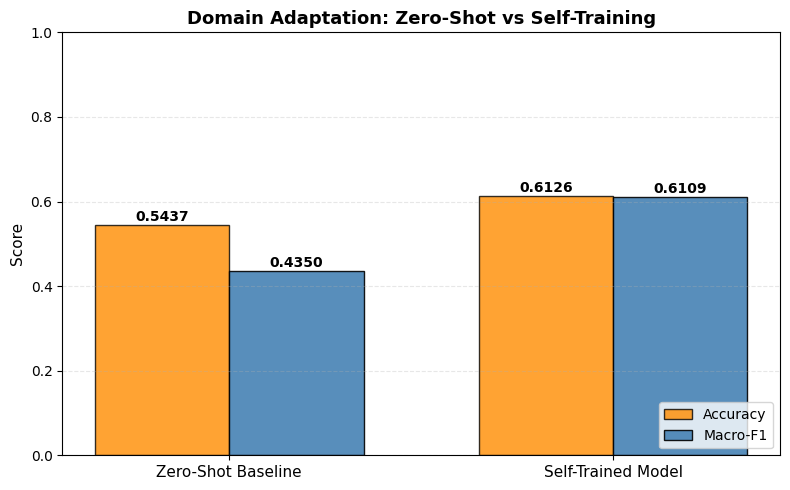

In [5]:
import json
import pandas as pd
import matplotlib.pyplot as plt

with open('logs/self_training_metrics.json') as f:
    results = json.load(f)

df = pd.DataFrame(results["metrics"])
print(f"\nTotal Pseudo-labeled Samples used for training: {results['accepted_samples']:,}\n")
print(df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
x = range(len(df))
width = 0.35

ax.bar([i - width/2 for i in x], df["Accuracy"], width, label='Accuracy', color='darkorange', edgecolor='black', alpha=0.8)
ax.bar([i + width/2 for i in x], df["Macro-F1"], width, label='Macro-F1', color='steelblue', edgecolor='black', alpha=0.9)

for i in x:
    ax.text(i - width/2, df["Accuracy"][i] + 0.01, f'{df["Accuracy"][i]:.4f}', ha='center', fontweight='bold')
    ax.text(i + width/2, df["Macro-F1"][i] + 0.01, f'{df["Macro-F1"][i]:.4f}', ha='center', fontweight='bold')

print()
print()

ax.set_xticks(x)
ax.set_xticklabels(df["Model"], fontsize=11)
ax.set_ylabel("Score", fontsize=11)
ax.set_title("Domain Adaptation: Zero-Shot vs Self-Training", fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.set_ylim(0, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Conclusion

**Key Finding:** Using the Self-Training (Pseudo-Labeling) method, the model successfully improved its performance on the target domain (Tweets) without requiring **ANY** human-annotated labels. By setting strict confidence thresholds, we effectively generated a high-quality training dataset and bridged the domain gap.
